In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import math
import torch
import matplotlib.pyplot as plt

def find_repo_root(start_path=None):
    current = (start_path or Path.cwd()).resolve()
    while True:
        if (current / "data").is_dir() and (current / "data_setup").is_dir():
            return current
        if current.parent == current:
            break
        current = current.parent
    raise RuntimeError("Could not locate necst-torch root directory")

REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

from src.utils import build_dataloaders

train_loader, valid_loader, test_loader, input_dim = build_dataloaders(
    dataset_name="binarymnist",
    datadir=str(REPO_ROOT / "data"),
    batch_size=100,
    return_labels=True,
)

# quick sanity check
batch = next(iter(train_loader))
imgs, labels = batch if isinstance(batch, (list, tuple)) else (batch, None)
print("Train batch shape:", imgs.shape, "min/max:", imgs.min().item(), imgs.max().item())
if labels is not None:
    print("Train labels shape:", labels.shape)
batch = imgs


Train batch shape: torch.Size([100, 1, 28, 28]) min/max: 0.0 1.0
Train labels shape: torch.Size([100])


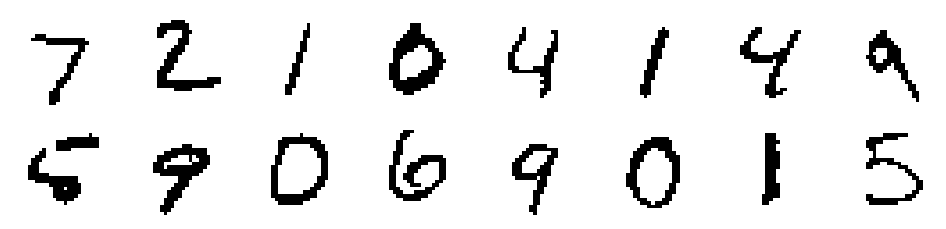

In [2]:
import matplotlib.pyplot as plt

def plot_binary_rows(data_loader, n_rows=2, n_cols=8):
    batch = next(iter(data_loader))
    imgs = batch[0] if isinstance(batch, (list, tuple)) else batch  # handles (imgs, labels) or imgs
    imgs = imgs[: n_rows * n_cols].detach().cpu()
    px = int(imgs.shape[-1] ** 0.5) if imgs.dim() == 2 else imgs.shape[-2]
    imgs = imgs.view(-1, px, px)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.2, n_rows * 1.2))
    for idx, img in enumerate(imgs):
        r, c = divmod(idx, n_cols)
        axes[r, c].imshow(img, cmap="gray_r", vmin=0, vmax=1)
        axes[r, c].axis("off")
    plt.tight_layout()
    plt.show()

plot_binary_rows(test_loader)


In [3]:
### training noise 0.1 -- load model
import torch
from pathlib import Path
from src.necst import NecstTorch
from src.args import parse_architecture

ckpt_path = Path("../models/mnist_vimco.pt")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load(ckpt_path, map_location=device)
config = checkpoint.get("config", {})
state_dict = checkpoint.get("model_state", checkpoint)

# rebuild model with saved config (fallbacks if keys missing)
model = NecstTorch(
    input_dim=config.get("input_dim", 784),
    z_dim=config.get("latent_dim", 100),
    vimco_samples=config.get("vimco_samples", 5),
    noise=config.get("noise", 0.0),
    test_noise=config.get("test_noise", 0.0),
    encoder_layers=parse_architecture(config.get("enc_arch", "500")),
    decoder_layers=parse_architecture(config.get("dec_arch", "500,500")),
).to(device)

model.load_state_dict(state_dict)
model.eval()
print("Loaded model from", ckpt_path)

Loaded model from ../models/mnist_vimco.pt


### plot reconstructions

Test BCE per pixel: 0.084826 | per image: 66.509950


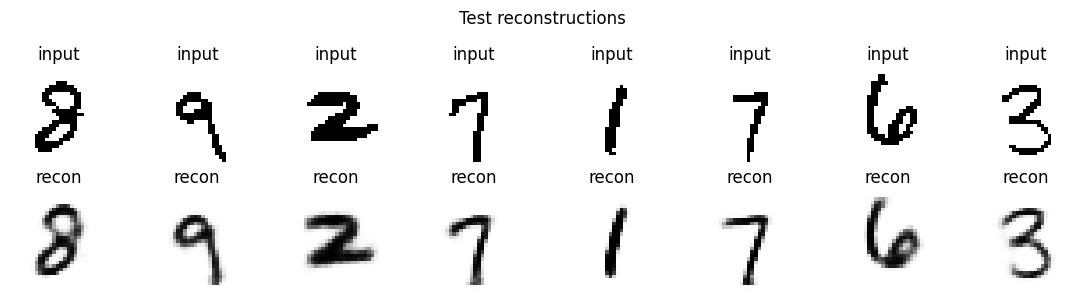

In [4]:
### plot reconstructions
### test noise 0.0
model.test_noise = 0.0

# test error (per sample/per image)
loss_per_pixel = model.get_loss(test_loader, per_element=True)
loss_per_image = model.get_loss(test_loader, per_element=False)
print(f"Test BCE per pixel: {loss_per_pixel:.6f} | per image: {loss_per_image:.6f}")

# image reconstructions
fig = model.plot_reconstructions(test_loader, n_samples=8, title="Test reconstructions", seed=123)
plt.show()

Test BCE per pixel: 0.101159 | per image: 79.427311


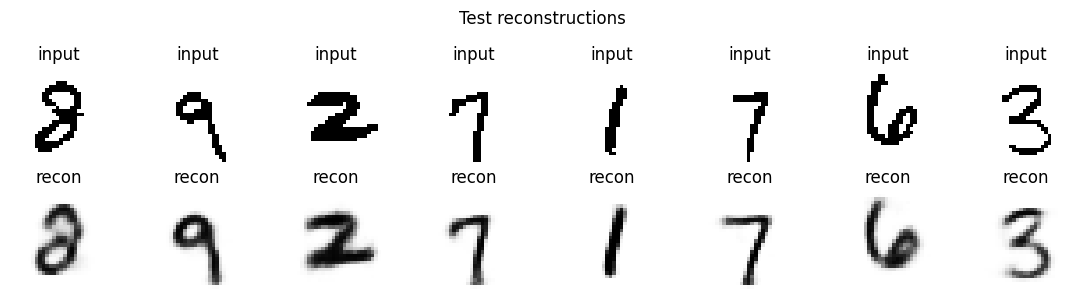

In [5]:
### plot reconstructions
### test noise 0.1
model.test_noise = 0.1

# test error (per sample/per image)
loss_per_pixel = model.get_loss(test_loader, per_element=True)
loss_per_image = model.get_loss(test_loader, per_element=False)
print(f"Test BCE per pixel: {loss_per_pixel:.6f} | per image: {loss_per_image:.6f}")

# image reconstructions
fig = model.plot_reconstructions(test_loader, n_samples=8, title="Test reconstructions", seed=123)
plt.show()

Test BCE per pixel: 0.134926 | per image: 105.949670


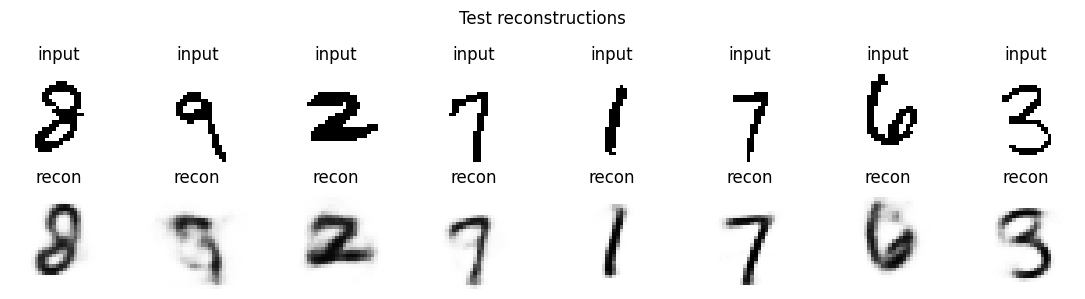

In [6]:
### plot reconstructions
### test noise 0.2
model.test_noise = 0.2

# test error (per sample/per image)
loss_per_pixel = model.get_loss(test_loader, per_element=True)
loss_per_image = model.get_loss(test_loader, per_element=False)
print(f"Test BCE per pixel: {loss_per_pixel:.6f} | per image: {loss_per_image:.6f}")

# image reconstructions
fig = model.plot_reconstructions(test_loader, n_samples=8, title="Test reconstructions", seed=123)
plt.show()

Test BCE per pixel: 0.199477 | per image: 155.487911


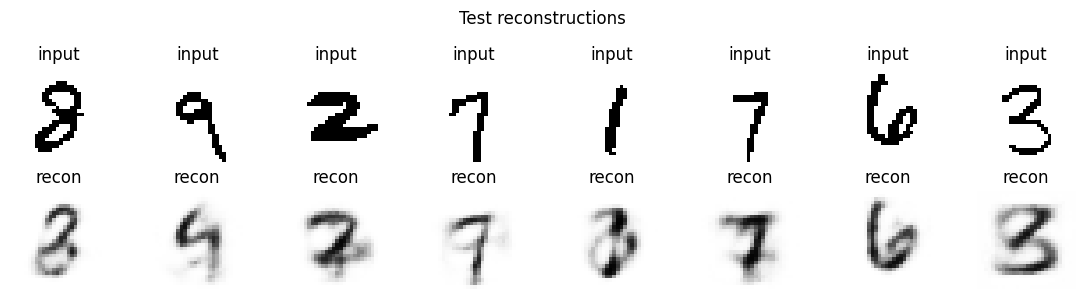

In [7]:
### plot reconstructions
### test noise 0.3
model.test_noise = 0.3

# test error (per sample/per image)
loss_per_pixel = model.get_loss(test_loader, per_element=True)
loss_per_image = model.get_loss(test_loader, per_element=False)
print(f"Test BCE per pixel: {loss_per_pixel:.6f} | per image: {loss_per_image:.6f}")

# image reconstructions
fig = model.plot_reconstructions(test_loader, n_samples=8, title="Test reconstructions", seed=123)
plt.show()

Test BCE per pixel: 0.290062 | per image: 226.771149


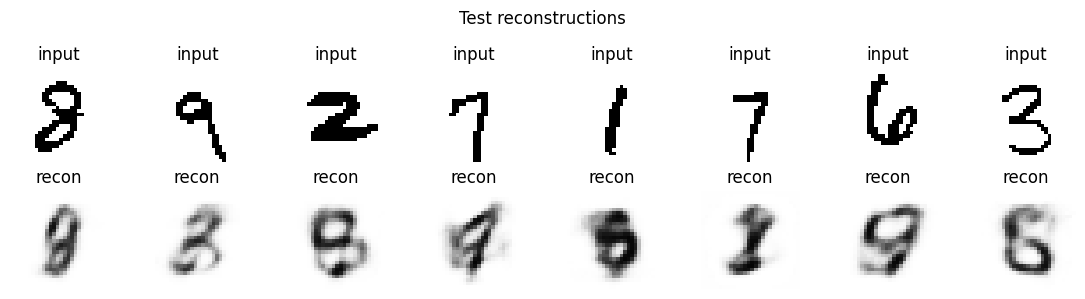

In [8]:
### plot reconstructions
### test noise 0.4
model.test_noise = 0.4

# test error (per sample/per image)
loss_per_pixel = model.get_loss(test_loader, per_element=True)
loss_per_image = model.get_loss(test_loader, per_element=False)
print(f"Test BCE per pixel: {loss_per_pixel:.6f} | per image: {loss_per_image:.6f}")

# image reconstructions
fig = model.plot_reconstructions(test_loader, n_samples=8, title="Test reconstructions", seed=123)
plt.show()

### latent space interpolation

two images selected:


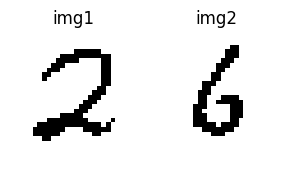

printing interpolation:


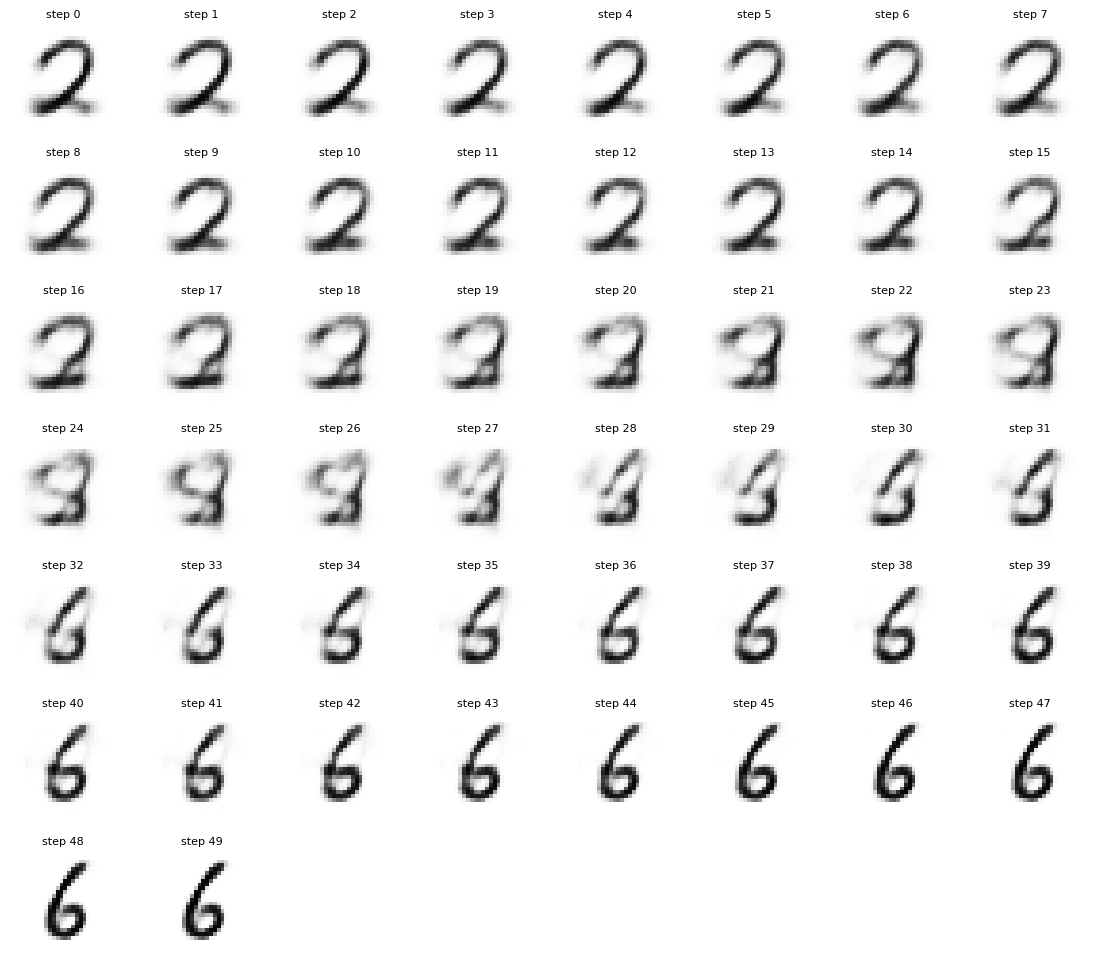

In [9]:
### interpolation example

model.test_noise = 0.1

import math, random, numpy as np, torch, matplotlib.pyplot as plt

# 1) deterministic loaders + sampling
SEED = 12114
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 2) grab the first batch from the non-shuffled test loader
batch = next(iter(test_loader))
imgs = batch[0] if isinstance(batch, (list, tuple)) else batch
img1 = imgs[35].to(device)
img2 = imgs[50].to(device)

print("two images selected:")
fig, axes = plt.subplots(1, 2, figsize=(3, 2))
axes[0].imshow(img1.view(28, 28).cpu(), cmap="gray_r", vmin=0, vmax=1)
axes[0].axis("off"); axes[0].set_title("img1")
axes[1].imshow(img2.view(28, 28).cpu(), cmap="gray_r", vmin=0, vmax=1)
axes[1].axis("off"); axes[1].set_title("img2")
plt.tight_layout(); plt.show()

# 3) run interpolation as before using img1/img2
print("printing interpolation:")
with torch.no_grad():
    y1, _, _ = model.sample_reconstruction(img1.unsqueeze(0))
    y2, _, _ = model.sample_reconstruction(img2.unsqueeze(0))

y1_vec, y2_vec = y1.squeeze(0).clone(), y2.squeeze(0).clone()
recons = []

def decode_bits(z_bits):
    logits = model.decoder(z_bits.unsqueeze(0))
    return torch.sigmoid(logits).view(28, 28).cpu()

with torch.no_grad():
    recons.append(decode_bits(y1_vec))
    for i in range(y1_vec.numel()):
        if y1_vec[i].item() != y2_vec[i].item():
            y1_vec[i] = y2_vec[i]
            recons.append(decode_bits(y1_vec))

cols = 8
rows = math.ceil(len(recons) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.4, rows * 1.4))
axes = axes.flatten()
for idx, img in enumerate(recons):
    axes[idx].imshow(img, cmap="gray_r", vmin=0, vmax=1)
    axes[idx].axis("off")
    axes[idx].set_title(f"step {idx}", fontsize=8)
for ax in axes[len(recons):]:
    ax.axis("off")
plt.tight_layout(); plt.show()


### downstream error

In [10]:
### downstream error
### classical classifiers on NECST embeddings
### noise = 0.0

model.test_noise = 0.0

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier


def encode_loader(data_loader):
    embeddings, labels = [], []
    model.eval()
    with torch.no_grad():
        for batch in data_loader:
            imgs, lbls = batch if isinstance(batch, (list, tuple)) else (batch, None)
            if lbls is None:
                raise ValueError("Loader must return (images, labels) tuples")
            imgs = imgs.to(device)
            y_bits, _, _ = model.sample_reconstruction(imgs)
            embeddings.append(y_bits.cpu())
            labels.append(lbls)
    feats = torch.cat(embeddings).numpy().astype(np.float32)
    lbl_array = torch.cat(labels).numpy()
    return feats, lbl_array


train_feats, train_labels = encode_loader(train_loader)
test_feats, test_labels = encode_loader(test_loader)

models = {
    "logistic_regression": LogisticRegression(max_iter=1000, solver="lbfgs"),
    "linear_svm": LinearSVC(max_iter=2000),
    "knn": KNeighborsClassifier(n_neighbors=5),
    "random_forest": RandomForestClassifier(
        n_estimators=200, random_state=42, n_jobs=-1
    ),
    "xgboost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        tree_method="hist",
        eval_metric="logloss",
        n_jobs=-1,
        use_label_encoder=False,
    ),
}

print("Generated embeddings:", train_feats.shape, test_feats.shape)

results = {}
for name, clf in models.items():
    print(f"Training {name}...")
    clf.fit(train_feats, train_labels)
    preds = clf.predict(test_feats)
    err = accuracy_score(test_labels, preds)
    results[name] = err
    # print(f"    test error = {err:.4f}")

print("Summary of test errors:")
for name, err in results.items():
    print(f"{name}: {err:.4f}")


Generated embeddings: (50000, 100) (10000, 100)
Training logistic_regression...
Training linear_svm...
Training knn...
Training random_forest...
Training xgboost...


/venv/necst/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [05:28:27] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Summary of test errors:
logistic_regression: 0.8955
linear_svm: 0.8906
knn: 0.9564
random_forest: 0.9559
xgboost: 0.9648


In [11]:
### downstream error
### classical classifiers on NECST embeddings
### noise = 0.1

model.test_noise = 0.1

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier


def encode_loader(data_loader):
    embeddings, labels = [], []
    model.eval()
    with torch.no_grad():
        for batch in data_loader:
            imgs, lbls = batch if isinstance(batch, (list, tuple)) else (batch, None)
            if lbls is None:
                raise ValueError("Loader must return (images, labels) tuples")
            imgs = imgs.to(device)
            y_bits, _, _ = model.sample_reconstruction(imgs)
            embeddings.append(y_bits.cpu())
            labels.append(lbls)
    feats = torch.cat(embeddings).numpy().astype(np.float32)
    lbl_array = torch.cat(labels).numpy()
    return feats, lbl_array


train_feats, train_labels = encode_loader(train_loader)
test_feats, test_labels = encode_loader(test_loader)

models = {
    "logistic_regression": LogisticRegression(max_iter=1000, solver="lbfgs"),
    "linear_svm": LinearSVC(max_iter=2000),
    "knn": KNeighborsClassifier(n_neighbors=5),
    "random_forest": RandomForestClassifier(
        n_estimators=200, random_state=42, n_jobs=-1
    ),
    "xgboost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        tree_method="hist",
        eval_metric="logloss",
        n_jobs=-1,
        use_label_encoder=False,
    ),
}

print("Generated embeddings:", train_feats.shape, test_feats.shape)

results = {}
for name, clf in models.items():
    print(f"Training {name}...")
    clf.fit(train_feats, train_labels)
    preds = clf.predict(test_feats)
    err = accuracy_score(test_labels, preds)
    results[name] = err
    # print(f"    test error = {err:.4f}")

print("Summary of test errors:")
for name, err in results.items():
    print(f"{name}: {err:.4f}")


Generated embeddings: (50000, 100) (10000, 100)
Training logistic_regression...
Training linear_svm...
Training knn...
Training random_forest...
Training xgboost...


/venv/necst/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [05:29:13] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Summary of test errors:
logistic_regression: 0.8174
linear_svm: 0.8118
knn: 0.9113
random_forest: 0.8858
xgboost: 0.9154


In [12]:
### downstream error
### classical classifiers on NECST embeddings
### noise = 0.2

model.test_noise = 0.2

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier


def encode_loader(data_loader):
    embeddings, labels = [], []
    model.eval()
    with torch.no_grad():
        for batch in data_loader:
            imgs, lbls = batch if isinstance(batch, (list, tuple)) else (batch, None)
            if lbls is None:
                raise ValueError("Loader must return (images, labels) tuples")
            imgs = imgs.to(device)
            y_bits, _, _ = model.sample_reconstruction(imgs)
            embeddings.append(y_bits.cpu())
            labels.append(lbls)
    feats = torch.cat(embeddings).numpy().astype(np.float32)
    lbl_array = torch.cat(labels).numpy()
    return feats, lbl_array


train_feats, train_labels = encode_loader(train_loader)
test_feats, test_labels = encode_loader(test_loader)

models = {
    "logistic_regression": LogisticRegression(max_iter=1000, solver="lbfgs"),
    "linear_svm": LinearSVC(max_iter=2000),
    "knn": KNeighborsClassifier(n_neighbors=5),
    "random_forest": RandomForestClassifier(
        n_estimators=200, random_state=42, n_jobs=-1
    ),
    "xgboost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        tree_method="hist",
        eval_metric="logloss",
        n_jobs=-1,
        use_label_encoder=False,
    ),
}

print("Generated embeddings:", train_feats.shape, test_feats.shape)

results = {}
for name, clf in models.items():
    print(f"Training {name}...")
    clf.fit(train_feats, train_labels)
    preds = clf.predict(test_feats)
    err = accuracy_score(test_labels, preds)
    results[name] = err
    # print(f"    test error = {err:.4f}")

print("Summary of test errors:")
for name, err in results.items():
    print(f"{name}: {err:.4f}")


Generated embeddings: (50000, 100) (10000, 100)
Training logistic_regression...
Training linear_svm...
Training knn...
Training random_forest...
Training xgboost...


/venv/necst/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [05:30:38] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Summary of test errors:
logistic_regression: 0.6976
linear_svm: 0.6946
knn: 0.7483
random_forest: 0.7222
xgboost: 0.7880


In [13]:
### downstream error
### classical classifiers on NECST embeddings
### noise = 0.3

model.test_noise = 0.3

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier


def encode_loader(data_loader):
    embeddings, labels = [], []
    model.eval()
    with torch.no_grad():
        for batch in data_loader:
            imgs, lbls = batch if isinstance(batch, (list, tuple)) else (batch, None)
            if lbls is None:
                raise ValueError("Loader must return (images, labels) tuples")
            imgs = imgs.to(device)
            y_bits, _, _ = model.sample_reconstruction(imgs)
            embeddings.append(y_bits.cpu())
            labels.append(lbls)
    feats = torch.cat(embeddings).numpy().astype(np.float32)
    lbl_array = torch.cat(labels).numpy()
    return feats, lbl_array


train_feats, train_labels = encode_loader(train_loader)
test_feats, test_labels = encode_loader(test_loader)

models = {
    "logistic_regression": LogisticRegression(max_iter=1000, solver="lbfgs"),
    "linear_svm": LinearSVC(max_iter=2000),
    "knn": KNeighborsClassifier(n_neighbors=5),
    "random_forest": RandomForestClassifier(
        n_estimators=200, random_state=42, n_jobs=-1
    ),
    "xgboost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        tree_method="hist",
        eval_metric="logloss",
        n_jobs=-1,
        use_label_encoder=False,
    ),
}

print("Generated embeddings:", train_feats.shape, test_feats.shape)

results = {}
for name, clf in models.items():
    print(f"Training {name}...")
    clf.fit(train_feats, train_labels)
    preds = clf.predict(test_feats)
    err = accuracy_score(test_labels, preds)
    results[name] = err
    # print(f"    test error = {err:.4f}")

print("Summary of test errors:")
for name, err in results.items():
    print(f"{name}: {err:.4f}")


Generated embeddings: (50000, 100) (10000, 100)
Training logistic_regression...
Training linear_svm...
Training knn...
Training random_forest...
Training xgboost...


/venv/necst/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [05:31:06] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Summary of test errors:
logistic_regression: 0.5142
linear_svm: 0.5074
knn: 0.3700
random_forest: 0.4620
xgboost: 0.5449


In [14]:
### downstream error
### classical classifiers on NECST embeddings
### noise = 0.4

model.test_noise = 0.4

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier


def encode_loader(data_loader):
    embeddings, labels = [], []
    model.eval()
    with torch.no_grad():
        for batch in data_loader:
            imgs, lbls = batch if isinstance(batch, (list, tuple)) else (batch, None)
            if lbls is None:
                raise ValueError("Loader must return (images, labels) tuples")
            imgs = imgs.to(device)
            y_bits, _, _ = model.sample_reconstruction(imgs)
            embeddings.append(y_bits.cpu())
            labels.append(lbls)
    feats = torch.cat(embeddings).numpy().astype(np.float32)
    lbl_array = torch.cat(labels).numpy()
    return feats, lbl_array


train_feats, train_labels = encode_loader(train_loader)
test_feats, test_labels = encode_loader(test_loader)

models = {
    "logistic_regression": LogisticRegression(max_iter=1000, solver="lbfgs"),
    "linear_svm": LinearSVC(max_iter=2000),
    "knn": KNeighborsClassifier(n_neighbors=5),
    "random_forest": RandomForestClassifier(
        n_estimators=200, random_state=42, n_jobs=-1
    ),
    "xgboost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        tree_method="hist",
        eval_metric="logloss",
        n_jobs=-1,
        use_label_encoder=False,
    ),
}

print("Generated embeddings:", train_feats.shape, test_feats.shape)

results = {}
for name, clf in models.items():
    print(f"Training {name}...")
    clf.fit(train_feats, train_labels)
    preds = clf.predict(test_feats)
    err = accuracy_score(test_labels, preds)
    results[name] = err
    # print(f"    test error = {err:.4f}")

print("Summary of test errors:")
for name, err in results.items():
    print(f"{name}: {err:.4f}")


Generated embeddings: (50000, 100) (10000, 100)
Training logistic_regression...
Training linear_svm...
Training knn...
Training random_forest...
Training xgboost...


/venv/necst/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [05:31:32] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Summary of test errors:
logistic_regression: 0.2740
linear_svm: 0.2713
knn: 0.1405
random_forest: 0.2087
xgboost: 0.2576


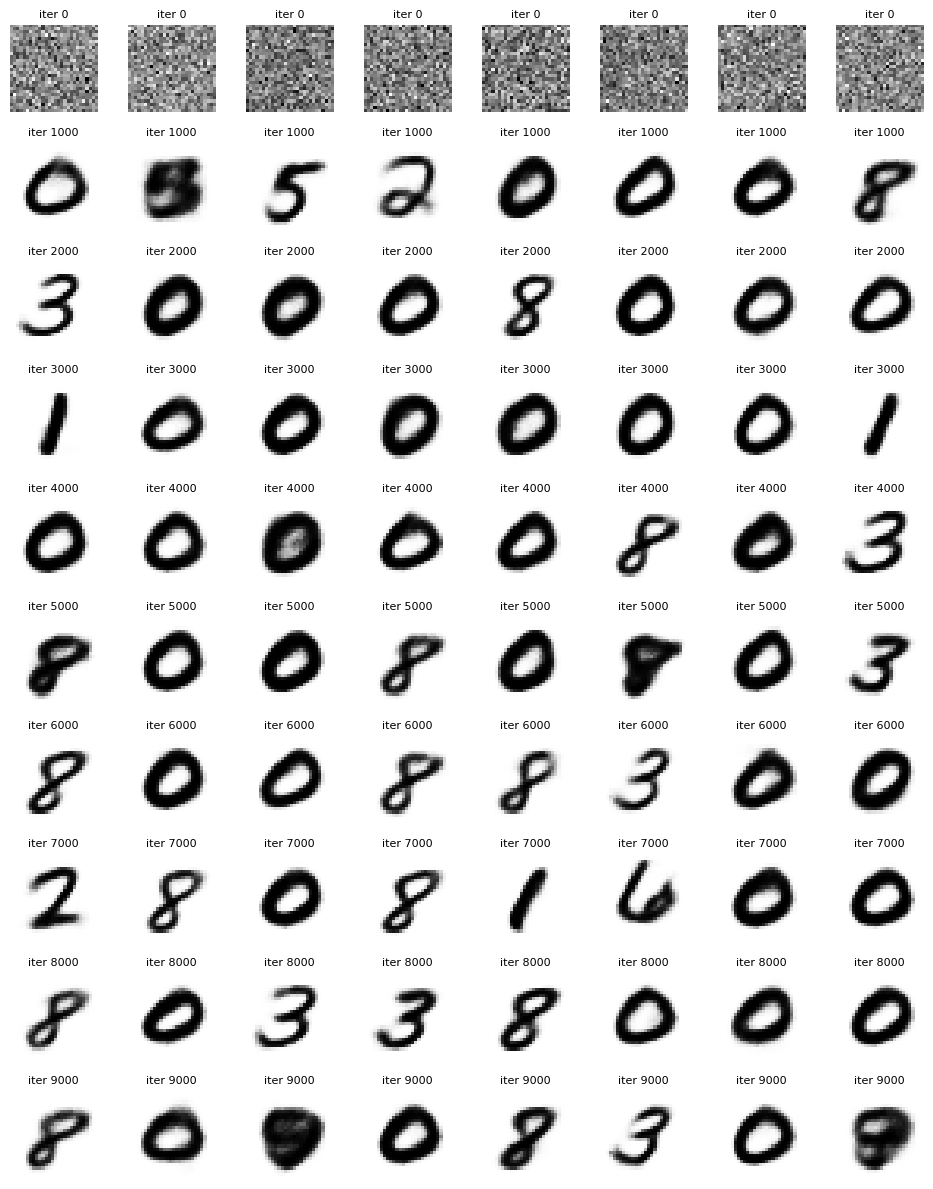

In [15]:
import torch
import matplotlib.pyplot as plt

model.test_noise = 0.1

batch_size = 8
h, w = 28, 28
device = next(model.parameters()).device
std = 0.5 ** 0.5

checkpoints = list(range(0, 9001, 1000))  # 0, 1000, ..., 9000
snapshots = []

# Initial noise sampled once
current = torch.normal(
    mean=0.0,
    std=std,
    size=(batch_size, 1, h, w),
    device=device,
)

with torch.no_grad():
    for step in range(0, checkpoints[-1] + 1):
        # Store at checkpoints
        if step in checkpoints:
            snapshots.append(
                (
                    step,
                    current.cpu().squeeze(1).clone(),  # current input
                )
            )

        # Forward pass and feed back for next step
        _, _, recon_logits = model.sample_reconstruction(current)
        current = torch.sigmoid(recon_logits).view(batch_size, 1, h, w)

# Plot: first row = initial noise; subsequent rows = reconstructions at each checkpoint
rows = len(checkpoints)
fig, axes = plt.subplots(rows, batch_size, figsize=(batch_size * 1.2, rows * 1.2))

for r, (step, imgs) in enumerate(snapshots):
    for c in range(batch_size):
        axes[r, c].imshow(imgs[c], cmap="gray_r")
        axes[r, c].set_title(f"iter {step}", fontsize=8)
        axes[r, c].axis("off")

plt.tight_layout()
plt.show()
